In [2]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

<Figure size 800x600 with 0 Axes>

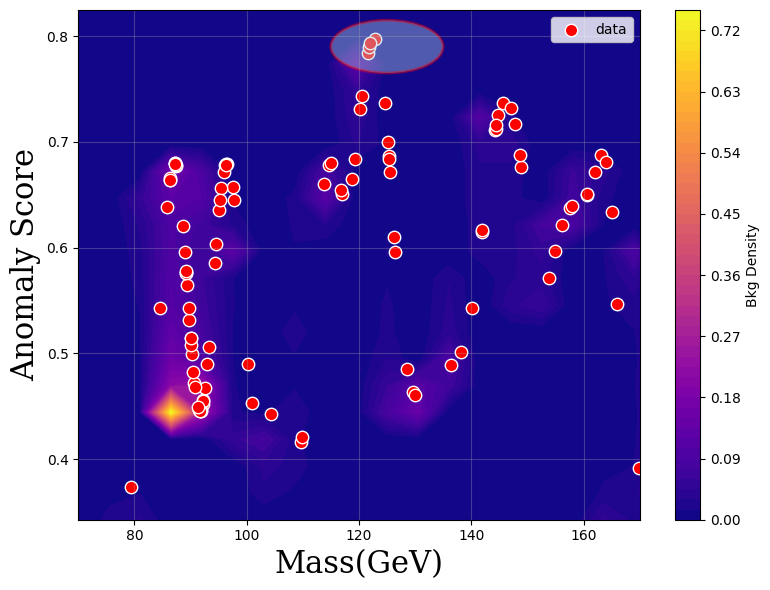

<Figure size 800x600 with 0 Axes>

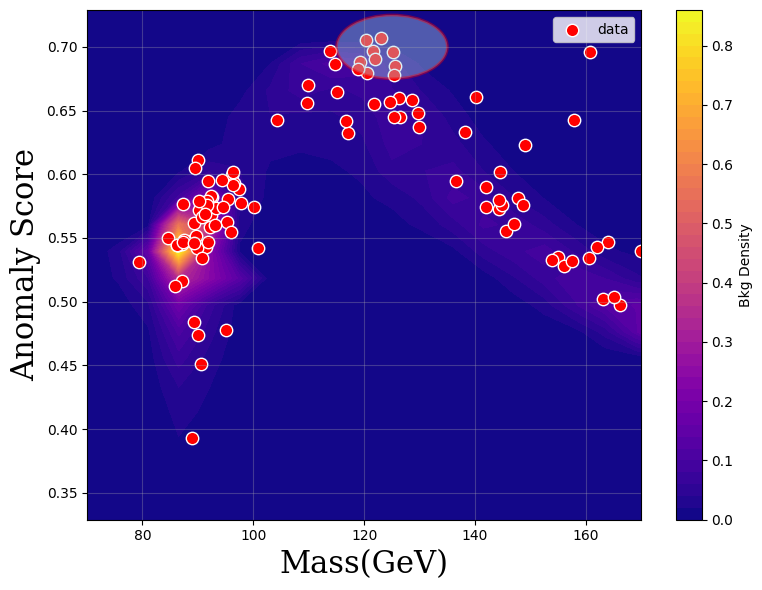

<Figure size 800x600 with 0 Axes>

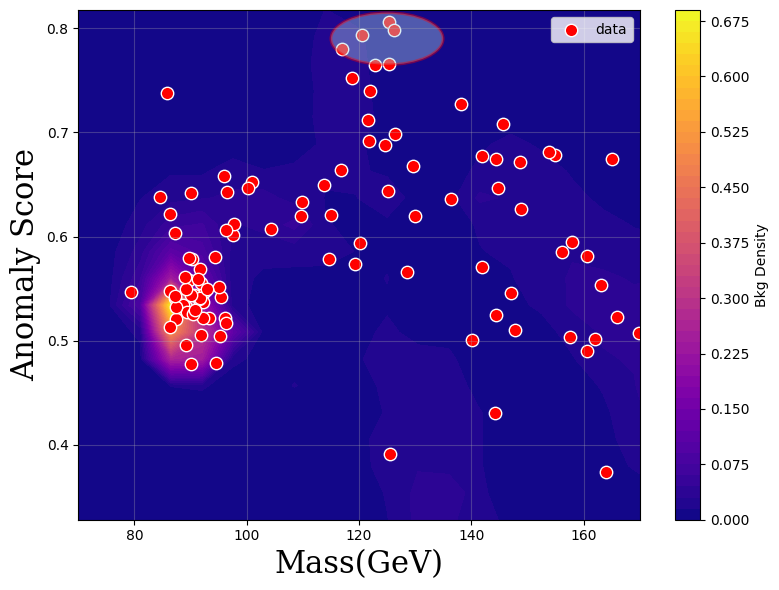

In [85]:
def plot2D(iFile="plt_vals_sup_tight.npz",iXMin=70,iXMax=170,iEllipse=True,iY=0.7,iYW=0.05,iYMax=0.75):
    file = np.load(iFile)
    #print(file.keys())
    mc=file["s_mc"]
    m_mc=file["m_mc"]
    mc_weights=file["w_mc"]
    data=file["s_da"]
    m_data=file["m_da"]
    m_mc = np.append(m_mc,125)
    mc   = np.append(mc,iYMax)
    mc_weights = np.append(mc_weights,0.0001)
    # Create the contourf background                                                                                                                                                                                                                         
    fig = plt.figure(figsize=(8, 6))
    hist, xedges, yedges = np.histogram2d(m_mc, mc, bins=20, weights=mc_weights, density=True)
    plt.figure(figsize=(8, 6))
    X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
    plt.contourf(X, Y, hist.T, levels=50, cmap='plasma')
    plt.colorbar(label='Bkg Density')
    plt.scatter(m_data, data, c='red', edgecolors='white', s=80,label='data')
    plt.xlim(iXMin,iXMax)
    fig.patch.set_facecolor('white')
    if iEllipse:
        center_x = 125
        center_y = iY
        width_x = 20       # Total width (not radius)
        height_y = iYW    # Total height (not radius)
        ellipse = Ellipse((center_x, center_y), width_x, height_y,edgecolor='red', facecolor='lightblue', lw=2, alpha=0.4)
        plt.gca().add_patch(ellipse)

    # Make it look nice                                                                                                                                                                                                                                      
    plt.xlabel('Mass(GeV)',fontsize=22, fontname='serif')
    plt.ylabel('Anomaly Score',fontsize=22, fontname='serif')
    #plt.zaxis('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

plot2D("plt_vals_mass_tight.npz",iYMax=0.85,iY=0.79,iYW=0.05)
plot2D("tmp2/plot_higgs_ctr_sup_tight_2d_v2.npz")
plot2D("tmp2/plot_higgs_ctr_tight_2d.npz",iY=0.79,iYW=0.05)

KeysView(NpzFile 'higgs_base_nll_toys_tight.npz' with keys: toy_higgs, toy_bkg)


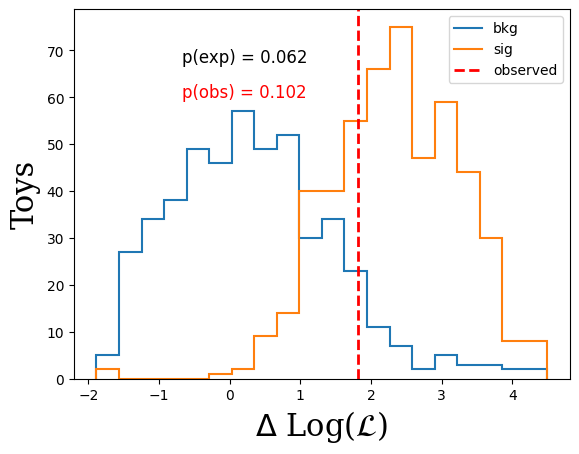

KeysView(NpzFile 'tmp2/higgs_base_toys_500_v6_1k.npz' with keys: toy_higgs, toy_bkg)


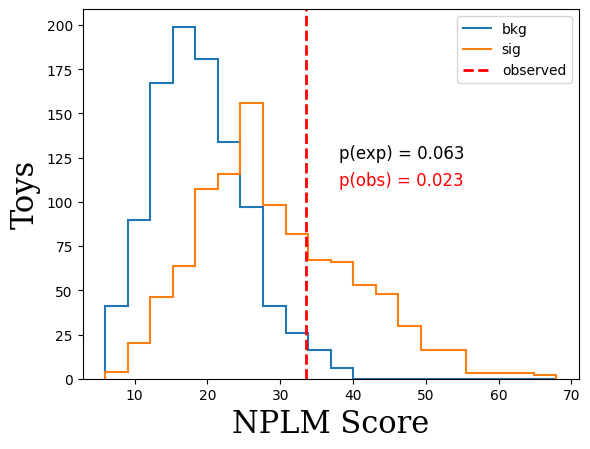

KeysView(NpzFile 'tmp2/model_higgs_seed10010nplm_toys_ctr_sup_space_tight_30k.npz' with keys: toy_sig, toy_bkg)


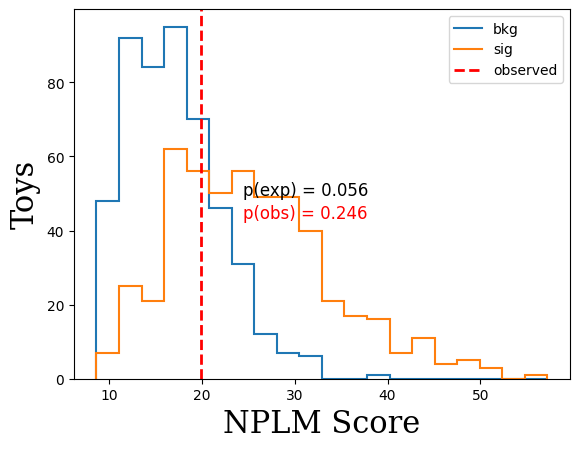

KeysView(NpzFile 'tmp2/model_higgs_seed10004nplm_toys_ctr_sup_space_tight.npz' with keys: toy_sig, toy_bkg)


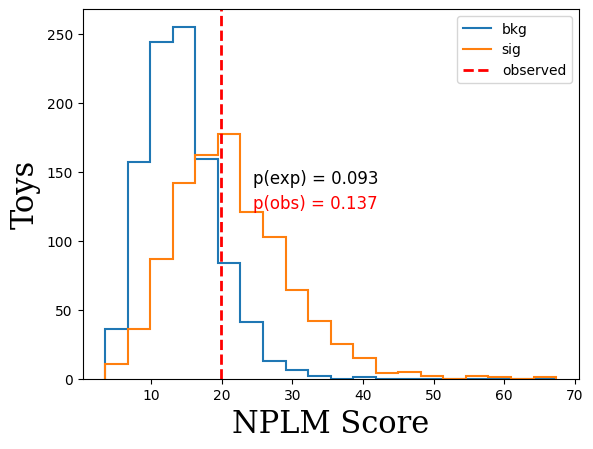

KeysView(NpzFile 'tmp2/model_higgs_seed10005nplm_toys_ctr_space_tight.npz' with keys: toy_sig, toy_bkg)


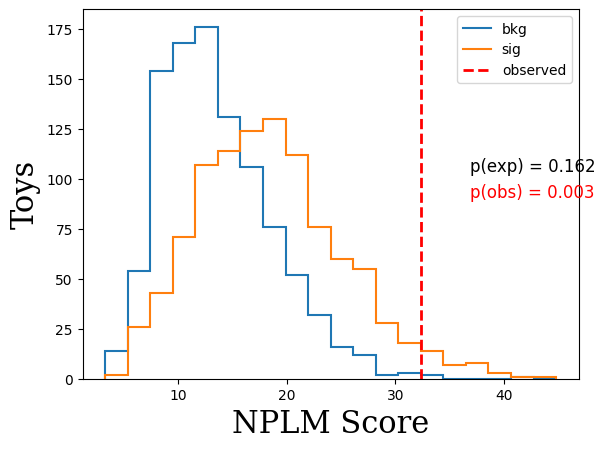

In [99]:
def plotPvalue(iFile,obsval,label='toy_higgs',LL=False):
    file = np.load(iFile)
    print(file.keys())
    bkg=file["toy_bkg"]
    sig=file[label]
    sig_vals,bins=np.histogram(file[label],bins=20)
    bkg_vals,bins=np.histogram(file["toy_bkg"],bins=bins)
    #diff_vals,bins=np.histogram(file["toy_sig"]-file["toy_bkg"],bins=bins)
    bin_center = 0.5*(bins[1:]+bins[:-1])
    plt.stairs(bkg_vals,bins,label='bkg',lw=1.5)
    plt.stairs(sig_vals,bins,label='sig',lw=1.5)
    #plt.stairs(diff_vals,bins,label='diff')
    plt.axvline(x=obsval, color='r', linestyle='--', label='observed',lw=2)
    z_obs = norm.ppf(0.5*float(len(bkg[bkg > obsval]))/len(bkg))
    z_exp = norm.ppf(0.5*float(len(bkg[bkg > sig.mean()]))/len(bkg))
    p_obs = float(len(bkg[bkg > obsval]))/len(bkg)
    p_exp = float(len(bkg[bkg > sig.mean()]))/len(bkg)
    #print('obs p-value:',float(len(bkg[bkg > obsval]))/len(bkg),z_obs)
    #print('exp p-value:',float(len(bkg[bkg > sig.mean()]))/len(bkg),z_exp)
    #print(bkg.mean(),sig.mean())

    if LL:
        ymax=np.max(sig_vals)
        formatted_value = f"{p_obs:.3g}"   # e.g. "0.0123"
        plt.text(obsval-2.5, 0.8*ymax, f"p(obs) = {formatted_value}", fontsize=12, color='red')
        formatted_value = f"{p_exp:.3g}"   # e.g. "0.0123"
        plt.text(obsval-2.5, 0.9*ymax, f"p(exp) = {formatted_value}", fontsize=12, color='black')        
    else:
        ymax=np.max(sig_vals)
        formatted_value = f"{p_obs:.3g}"   # e.g. "0.0123"
        plt.text(obsval+4.5, 0.7*ymax, f"p(obs) = {formatted_value}", fontsize=12, color='red')
        formatted_value = f"{p_exp:.3g}"   # e.g. "0.0123"
        plt.text(obsval+4.5, 0.8*ymax, f"p(exp) = {formatted_value}", fontsize=12, color='black')
    
    if LL:
        plt.xlabel('$\Delta$ Log($\mathcal{L}$)',fontsize=22, fontname='serif')
    else:
        plt.xlabel('NPLM Score',fontsize=22, fontname='serif')
    plt.ylabel('Toys',fontsize=22, fontname='serif')
    plt.legend()
    plt.show() 
plotPvalue("higgs_base_nll_toys_tight.npz",1.82,LL=True)
plotPvalue("tmp2/higgs_base_toys_500_v6_1k.npz",obsval=33.6)
plotPvalue("tmp2/model_higgs_seed10010nplm_toys_ctr_sup_space_tight_30k.npz",19.9,label='toy_sig')#30kernels 4d
plotPvalue("tmp2/model_higgs_seed10004nplm_toys_ctr_sup_space_tight.npz",label='toy_sig',obsval=19.9)#20 kernels 4d
plotPvalue("tmp2/model_higgs_seed10005nplm_toys_ctr_space_tight.npz",label='toy_sig',obsval=32.4)

KeysView(NpzFile 'model_higgs_seed5001nplm_toys_mass_tight.npz' with keys: toy_sig, toy_bkg)


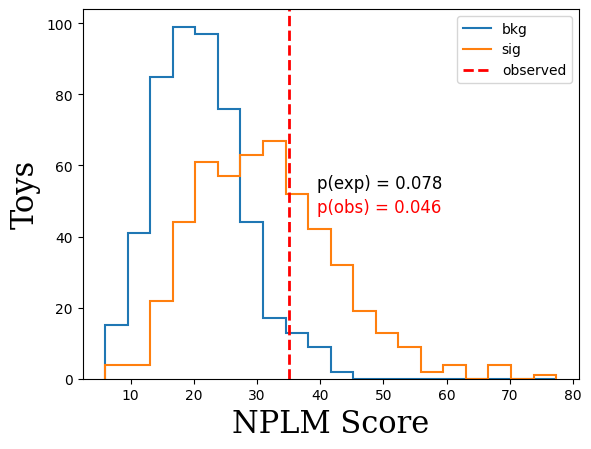

KeysView(NpzFile 'higgs_base_nll_toys_tight.npz' with keys: toy_higgs, toy_bkg)


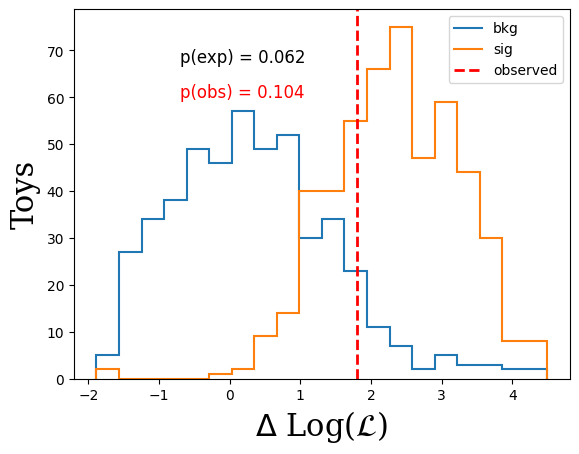

KeysView(NpzFile 'model_higgs_nplm_toys_ctr_space_tight.npz' with keys: toy_sig, toy_bkg)


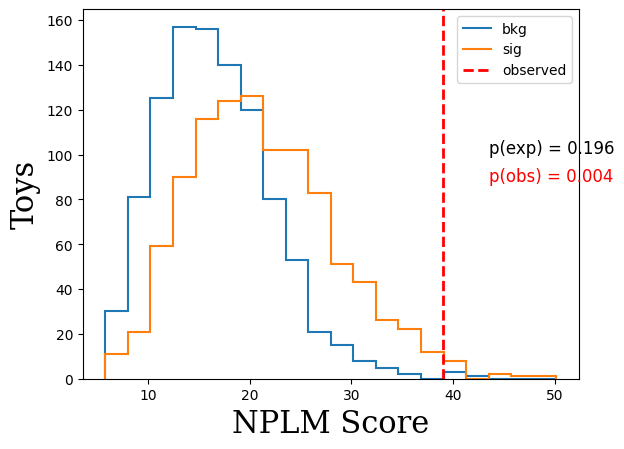

KeysView(NpzFile 'model_higgs_nplm_toys_ctr_sup_space_tight_merge.npz' with keys: toy_sig, toy_bkg)


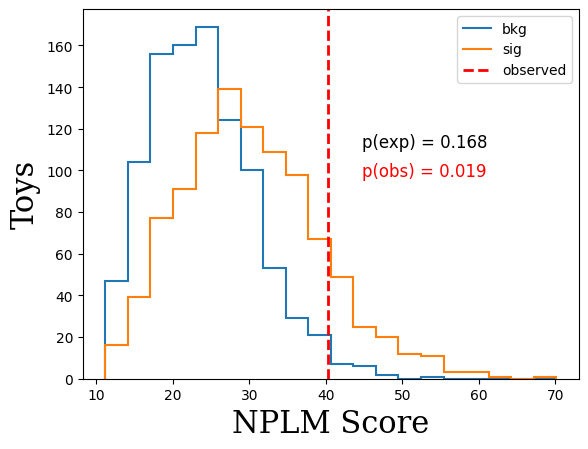

In [97]:
plotPvalue("model_higgs_seed5001nplm_toys_mass_tight.npz",obsval=35.,label='toy_sig')
plotPvalue("higgs_base_nll_toys_tight.npz",obsval=1.8,LL=True)
plotPvalue("model_higgs_nplm_toys_ctr_space_tight.npz",obsval=39,label='toy_sig')
plotPvalue("model_higgs_nplm_toys_ctr_sup_space_tight_merge.npz",obsval=40.3,label="toy_sig")


KeysView(NpzFile 'higgs_base_nll_toys_tight.npz' with keys: toy_higgs, toy_bkg)


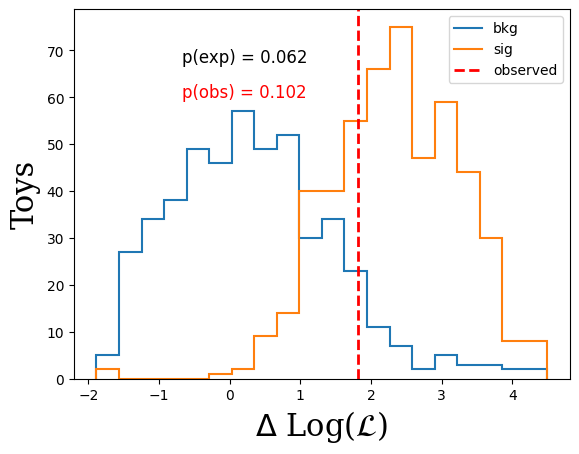

KeysView(NpzFile 'tmp2/higgs_base_toys_500_v6_1k.npz' with keys: toy_higgs, toy_bkg)


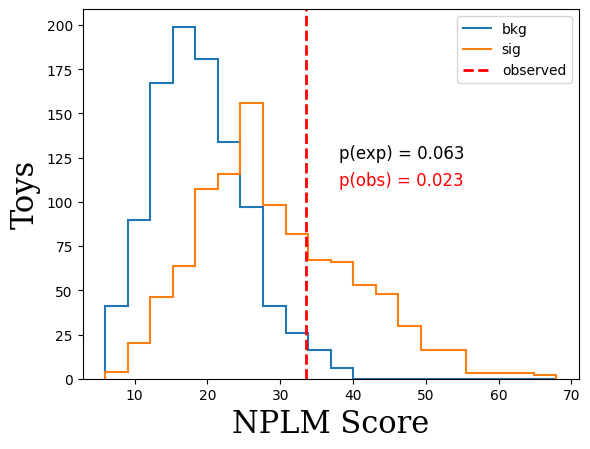

KeysView(NpzFile 'tmp2/model_higgs_seed10011nplm_toys_ctr_sup_space_tight_2d.npz' with keys: toy_sig, toy_bkg)


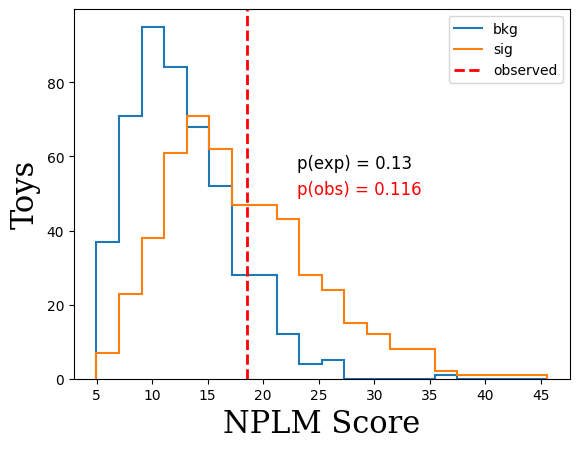

KeysView(NpzFile 'tmp2/model_higgs_seed10010nplm_toys_ctr_space_tight_2d.npz' with keys: toy_sig, toy_bkg)


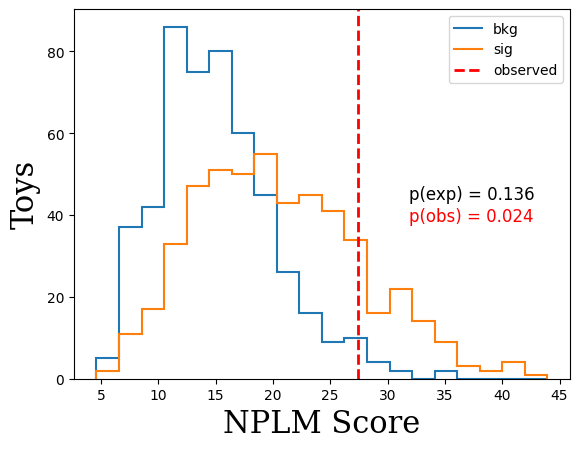

In [92]:
plotPvalue("higgs_base_nll_toys_tight.npz",1.82,LL=True)
plotPvalue("tmp2/higgs_base_toys_500_v6_1k.npz",obsval=33.6)
plotPvalue("tmp2/model_higgs_seed10011nplm_toys_ctr_sup_space_tight_2d.npz",label='toy_sig',obsval=18.5)
plotPvalue("tmp2/model_higgs_seed10010nplm_toys_ctr_space_tight_2d.npz",label='toy_sig',obsval=27.4)